In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import os
import pandas as pd
from transformers import ASTFeatureExtractor, ASTModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import roc_auc_score

Shape: (128, 313)
Min: -51.48 dB | Max: 0.00 dB


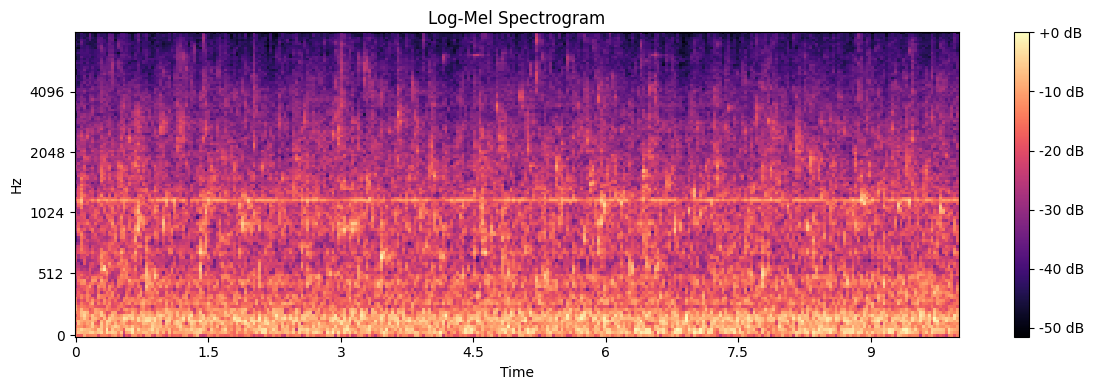

In [79]:


def extract_log_mel_spectrogram(
    audio_path: str,
    sr: int = 16000,
    n_fft: int = 1024,
    hop_length: int = 512,
    n_mels: int = 128,
    fmin: float = 0.0,
    fmax: float = None
) -> np.ndarray:
    """
    Extract log-mel spectrogram from an audio file.

    Args:
        audio_path : Path to audio file
        sr         : Target sampling rate
        n_fft      : FFT window size
        hop_length : Hop length between frames
        n_mels     : Number of mel filterbanks
        fmin       : Minimum frequency (Hz)
        fmax       : Maximum frequency (Hz), defaults to sr/2

    Returns:
        log_mel_spec : Log-mel spectrogram (n_mels x T) in dB
    """
    # Load audio
    y, sr = librosa.load(audio_path, sr=sr)

    # Compute mel spectrogram (power spectrogram)
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels#,
        # fmin=fmin,
        # fmax=fmax,
        # power=2.0          # Power spectrogram (magnitude²)
    )

    # Convert to log scale (dB), using peak power as reference
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    return log_mel_spec, sr


def plot_log_mel_spectrogram(log_mel_spec: np.ndarray, sr: int, hop_length: int = 512):
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        log_mel_spec,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis="mel",
        cmap="magma"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title("Log-Mel Spectrogram")
    plt.tight_layout()
    plt.show()



path = r"data\0_dB_pump\pump\id_00\normal\00000000.wav"   # replace with your file

log_mel, sr = extract_log_mel_spectrogram(
    audio_path=path,
    sr=16000,
    n_fft=1024,
    hop_length=512,
    n_mels=128#,
    # fmin=50.0,
    # fmax=8000.0
)

print(f"Shape: {log_mel.shape}")   # (n_mels, time_frames)
print(f"Min: {log_mel.min():.2f} dB | Max: {log_mel.max():.2f} dB")

plot_log_mel_spectrogram(log_mel, sr, hop_length=512)

In [2]:
def build_mimii_pump_dataframe(root_dir):
    records = []
    machine_path= root_dir

    for condition in ["normal", "abnormal"]:
        condition_path = os.path.join(machine_path, condition)

        if not os.path.exists(condition_path):
            continue

        for file in os.listdir(condition_path):
            if file.endswith(".wav"):
                records.append({
                    "machine_id": "id_00",
                    "condition": condition,
                    "file_path": os.path.join(condition_path, file)
                })

    return pd.DataFrame(records)

In [81]:
def extract_embeddings(df,model):
    embeddings=[]   
    for file in df['file_path']: 
    #     log_mel, sr = extract_log_mel_spectrogram(
    #     audio_path=file,
    #     sr=16000,
    #     n_fft=1024,
    #     hop_length=512,
    #     n_mels=128#,
    #     # fmin=50.0,
    #     # fmax=8000.0
    # )
        waveform, sr = librosa.load(file, sr=16000)

        inputs = feature_extractor(
            waveform,
            sampling_rate=sr,
            return_tensors="pt"
        )
        with torch.no_grad():
            outputs = model(**inputs)

        # CLS token embedding
        embedding = outputs.last_hidden_state[:, 0, :]# (1, 768)
        embeddings.append(embedding.squeeze().numpy())
    return embeddings  

In [3]:
root_dir = r"data\0_dB_pump\pump\id_00"
df = build_mimii_pump_dataframe(root_dir)

print(df.head())
print(df["condition"].value_counts())

  machine_id condition                                      file_path
0      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000000.wav
1      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000001.wav
2      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000002.wav
3      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000003.wav
4      id_00    normal  data\0_dB_pump\pump\id_00\normal\00000004.wav
condition
normal      1006
abnormal     143
Name: count, dtype: int64


In [83]:
# Load pretrained AST
feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)
model = ASTModel.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ASTModel(
  (embeddings): ASTEmbeddings(
    (patch_embeddings): ASTPatchEmbeddings(
      (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ASTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ASTLayer(
        (attention): ASTAttention(
          (attention): ASTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ASTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ASTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ASTOutput(
          (d

In [4]:
df["label"] = df["condition"].map({"normal": 0, "abnormal": 1})

In [5]:
normal_df=df[df['condition']=='normal']
abnormal_df = df[df['condition']=='abnormal']
train_df = normal_df.iloc[:int(len(normal_df)*0.7)]
temp_df = pd.concat([normal_df.iloc[int(len(normal_df)*0.7):], abnormal_df])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, shuffle=True)

In [6]:
print("Validation Data:",val_df['condition'].value_counts())
print("Training Data:",train_df['condition'].value_counts())
print("Test Data:",test_df['condition'].value_counts())

Validation Data: condition
normal      155
abnormal     67
Name: count, dtype: int64
Training Data: condition
normal    704
Name: count, dtype: int64
Test Data: condition
normal      147
abnormal     76
Name: count, dtype: int64


In [87]:
train_set = np.vstack(extract_embeddings(train_df,model))
val_set = np.vstack(extract_embeddings(val_df,model))
test_set= np.vstack(extract_embeddings(test_df,model))

In [88]:
print("Training Data:",train_set.shape)
print("Validation Data:",val_set.shape)
print("Test Data:",test_set.shape)

Training Data: (704, 768)
Validation Data: (222, 768)
Test Data: (223, 768)


In [7]:
y_val = val_df['label'].values
y_test = test_df['label'].values

In [8]:


class DeepSVDD_Network(nn.Module):
    """
    Maps AST embeddings to a compact hypersphere latent space.
    No bias terms, no batch norm with learnable affine — prevents hypersphere collapse.
    """
    def __init__(self, input_dim: int = 768, hidden_dims: list = [512, 256, 128], rep_dim: int = 128):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers += [
                nn.Linear(in_dim, h_dim, bias=False),
                nn.BatchNorm1d(h_dim, affine=False),  # affine=False is critical
                nn.ReLU()
            ]
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, rep_dim, bias=False))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [9]:
class DeepSVDD:
    def __init__(self, rep_dim=128, nu=0.1, device="cuda"):
        """
        nu : float in (0,1] — upper bound on fraction of anomalies (soft-boundary)
        """
        self.rep_dim = rep_dim
        self.nu = nu
        self.device = device
        self.center = None
        self.radius = 0.0
        self.model = None

    def initialize_center(self, loader, model, eps=0.1):
        """
        One-class center c: mean of all training embeddings.
        Clamp near-zero dims to avoid collapse.
        """
        model.eval()
        all_z = []
        with torch.no_grad():
            for x, _ in loader:
                x = x.to(self.device)
                z = model(x)
                all_z.append(z)
        c = torch.cat(all_z).mean(dim=0)
        # Prevent center collapsing near origin
        c[(torch.abs(c) < eps) & (c < 0)] = -eps
        c[(torch.abs(c) < eps) & (c >= 0)] = eps
        return c

    def train(self, train_loader, val_loader, input_dim=768, hidden_dims=[512, 256, 128],
          n_epochs=50, lr=1e-4, weight_decay=1e-6, warm_up_epochs=10):

        self.model = DeepSVDD_Network(input_dim, hidden_dims, self.rep_dim).to(self.device)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[int(n_epochs * 0.5), int(n_epochs * 0.75)], gamma=0.1
        )

        self.center = self.initialize_center(train_loader, self.model).to(self.device)

        best_val_auc = 0.0
        best_weights = None

        for epoch in range(n_epochs):
            if epoch == warm_up_epochs:
                print(f"Initializing center at epoch {epoch}...")
                self.center = self.initialize_center(train_loader, self.model).to(self.device)
            # ── Training ──────────────────────────────────────────
            self.model.train()
            train_loss = 0.0

            for x, _ in train_loader:
                x = x.to(self.device)
                optimizer.zero_grad()

                z = self.model(x)

                if self.center is None:   # skip SVDD loss during warm-up
                    loss = torch.mean(torch.sum(z ** 2, dim=1))  # pretrain: push towards origin
                else:
                    dist = torch.sum((z - self.center) ** 2, dim=1)
                    scores = dist - self.radius ** 2
                    loss = self.radius ** 2 + (1 / self.nu) * torch.mean(torch.clamp(scores, min=0))
                    if epoch > warm_up_epochs:
                        self.radius = self._update_radius(dist)

                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            scheduler.step()

            # ── Validation ────────────────────────────────────────
            val_scores, val_labels = self.predict(val_loader)
            val_auc = roc_auc_score(val_labels, val_scores)

            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_weights = {k: v.clone() for k, v in self.model.state_dict().items()}

            if (epoch + 1) % 10 == 0:
                print(
                    f"Epoch [{epoch+1}/{n_epochs}] "
                    f"Train Loss: {train_loss/len(train_loader):.6f} | "
                    f"Val AUC: {val_auc:.4f} | "
                    f"Best Val AUC: {best_val_auc:.4f} | "
                    f"R: {self.radius:.4f}"
                )

        # Restore best model
        self.model.load_state_dict(best_weights)
        print(f"\nTraining complete. Best Val AUC: {best_val_auc:.4f}")

    def _update_radius(self, dist):
        """Radius = (1-nu) quantile of distances."""
        return torch.quantile(torch.sqrt(dist).detach(), 1 - self.nu).item()

    @torch.no_grad()
    def predict(self, loader):
        """Returns anomaly scores (distance from center). Higher = more anomalous."""
        self.model.eval()
        scores, labels = [], []
        for x, y in loader:
            x = x.to(self.device)
            z = self.model(x)
            dist = torch.sum((z - self.center) ** 2, dim=1)
            scores.extend(dist.cpu().numpy())
            labels.extend(y.numpy())
        return np.array(scores), np.array(labels)

In [92]:


# --- Assume ast_embeddings: np.ndarray of shape (N, 768) ---
# --- and labels: 0=normal, 1=anomaly (labels NOT used in training) ---

scaler = StandardScaler()
X_train_scaled = normalize(scaler.fit_transform(train_set))   # normal samples only
X_val_scaled  = normalize(scaler.transform(val_set))
X_test_scaled = normalize(scaler.transform(test_set))

train_tensor = TensorDataset(
    torch.FloatTensor(X_train_scaled),
    torch.zeros(len(X_train_scaled))  # dummy labels
)

val_tensor = TensorDataset(
    torch.FloatTensor(X_val_scaled),
    torch.FloatTensor(y_val)
)

test_tensor = TensorDataset(
    torch.FloatTensor(X_test_scaled),
    torch.FloatTensor(y_test)
)

train_loader = DataLoader(train_tensor, batch_size=64, shuffle=True,  drop_last=True)
test_loader  = DataLoader(test_tensor,  batch_size=64, shuffle=False)
val_loader   = DataLoader(val_tensor,   batch_size=64, shuffle=False)

# --- Train ---
svdd = DeepSVDD(rep_dim=128, nu=0.3, device="cuda")
svdd.train(
    train_loader,
    val_loader,          
    input_dim=768,
    hidden_dims=[512, 256],
    n_epochs=200,
    warm_up_epochs=10
)

# --- Evaluate ---
scores, labels = svdd.predict(test_loader)
auc = roc_auc_score(labels, scores)
print(f"ROC-AUC: {auc:.4f}")

Epoch [10/200] Train Loss: 4.002672 | Val AUC: 0.7973 | Best Val AUC: 0.8120 | R: 0.0000
Initializing center at epoch 10...
Epoch [20/200] Train Loss: 0.788596 | Val AUC: 0.8061 | Best Val AUC: 0.8167 | R: 0.8089
Epoch [30/200] Train Loss: 0.554610 | Val AUC: 0.8209 | Best Val AUC: 0.8249 | R: 0.6873
Epoch [40/200] Train Loss: 0.444395 | Val AUC: 0.8207 | Best Val AUC: 0.8278 | R: 0.6111
Epoch [50/200] Train Loss: 0.343489 | Val AUC: 0.8202 | Best Val AUC: 0.8324 | R: 0.5386
Epoch [60/200] Train Loss: 0.268806 | Val AUC: 0.8263 | Best Val AUC: 0.8395 | R: 0.5088
Epoch [70/200] Train Loss: 0.223694 | Val AUC: 0.8342 | Best Val AUC: 0.8428 | R: 0.4200
Epoch [80/200] Train Loss: 0.185511 | Val AUC: 0.8223 | Best Val AUC: 0.8428 | R: 0.3887
Epoch [90/200] Train Loss: 0.184557 | Val AUC: 0.8286 | Best Val AUC: 0.8428 | R: 0.4261
Epoch [100/200] Train Loss: 0.134902 | Val AUC: 0.8257 | Best Val AUC: 0.8428 | R: 0.3519
Epoch [110/200] Train Loss: 0.110617 | Val AUC: 0.8357 | Best Val AUC: 0.8

### Metrics Evaluation

In [93]:
# Checking if simply flipping scores fixes it
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, -scores))  # this gives ~0.54, scores are inverted

0.20289983988614124


In [94]:
print("Val  :", pd.Series(y_val).value_counts())
print("Test :", pd.Series(y_test).value_counts())

Val  : 0    156
1     66
Name: count, dtype: int64
Test : 0    146
1     77
Name: count, dtype: int64


In [20]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Isolation Forest
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train_scaled)
iso_scores = -iso.score_samples(X_test_scaled)
print("IsoForest AUC:", roc_auc_score(y_test, iso_scores))

# LOF
lof = LocalOutlierFactor(novelty=True, contamination=0.1)
lof.fit(X_train_scaled)
lof_scores = -lof.score_samples(X_test_scaled)
print("LOF AUC:", roc_auc_score(y_test, lof_scores))

IsoForest AUC: 0.7482098102398854
LOF AUC: 0.42633369137128535


In [19]:
#variance of latent vectors should be close to 0
z_all = []
with torch.no_grad():
    for x, _ in train_loader_emb:
        z_all.append(svdd.model(x.to(svdd.device)))
z_all = torch.cat(z_all)
print(z_all.std(dim=0).mean())   # should NOT be near 0

tensor(0.0603, device='cuda:0')




---

## Key Design Decisions

| Decision | Reason |
|---|---|
| `bias=False` in all layers | Prevents center collapse to origin |
| `BatchNorm(affine=False)` | Stabilizes training without shift/scale params |
| Warm-up before updating radius | Lets network form meaningful representations first |
| StandardScaler before input | AST embeddings can have large variance across dims |
| `nu` as hyperparameter | Tune based on expected anomaly rate in your data |

---

## Typical Flow for MIMII / Bearing Data

Raw WAV → Log-Mel Spectrogram → AST Encoder → [768-dim embedding]
                                                      ↓
                                            Deep SVDD Network
                                                      ↓
                                            128-dim latent space
                                                      ↓
                                         Distance from center c → anomaly score

In [10]:
feature_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
ast_model = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
class ASTFineTuner(nn.Module):
    def __init__(self, ast_model, hidden_size=768, mask_ratio=0.4):
        super().__init__()
        self.ast = ast_model
        self.mask_ratio = mask_ratio

        # Freeze all layers first
        for param in self.ast.parameters():
            param.requires_grad = False

        # Unfreeze only last 4 transformer blocks
        for layer in self.ast.encoder.layer[-4:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Reconstruction head
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, hidden_size)
        )

    def forward(self, input_values, mask=None):
        outputs = self.ast(input_values=input_values, output_hidden_states=True)
        patch_embeddings = outputs.last_hidden_state  # (B, num_patches, 768)

        if mask is not None:
            # Reconstruct masked patches
            reconstructed = self.decoder(patch_embeddings)
            return reconstructed, patch_embeddings, mask
        else:
            # Inference: return CLS + mean pooled embedding
            cls_emb  = patch_embeddings[:, 0, :]            # (B, 768)
            mean_emb = patch_embeddings[:, 1:, :].mean(1)   # (B, 768)
            return torch.cat([cls_emb, mean_emb], dim=1)    # (B, 1536)

    def generate_mask(self, batch_size, num_patches, device):
        num_mask = int(self.mask_ratio * num_patches)
        mask = torch.zeros(batch_size, num_patches, dtype=torch.bool, device=device)
        for i in range(batch_size):
            idx = torch.randperm(num_patches)[:num_mask]
            mask[i, idx] = True
        return mask

In [12]:
def finetune_ast(model, train_loader, val_loader, n_epochs=30, lr=1e-4, device="cuda"):
    model = model.to(device)
    
    # Only optimize unfrozen params
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_weights = None

    for epoch in range(n_epochs):
        # ── Train ──────────────────────────────────────────────
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            input_values = batch["input_values"].to(device)

            # Get number of patches from a forward pass
            with torch.no_grad():
                tmp = model.ast(input_values=input_values[:1])
                num_patches = tmp.last_hidden_state.shape[1] - 1  # exclude CLS

            mask = model.generate_mask(input_values.size(0), num_patches, device)

            optimizer.zero_grad()
            reconstructed, original, mask = model(input_values, mask=mask)

            # Loss only on masked patches (skip CLS token → offset by 1)
            mask_ext = mask.unsqueeze(-1).expand_as(reconstructed[:, 1:, :])
            loss = criterion(
                reconstructed[:, 1:, :][mask_ext],
                original[:, 1:, :][mask_ext].detach()
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        # ── Validate ───────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                input_values = batch["input_values"].to(device)
                tmp = model.ast(input_values=input_values[:1])
                num_patches = tmp.last_hidden_state.shape[1] - 1
                mask = model.generate_mask(input_values.size(0), num_patches, device)
                reconstructed, original, mask = model(input_values, mask=mask)
                mask_ext = mask.unsqueeze(-1).expand_as(reconstructed[:, 1:, :])
                loss = criterion(
                    reconstructed[:, 1:, :][mask_ext],
                    original[:, 1:, :][mask_ext].detach()
                )
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{n_epochs}] "
                  f"Train Loss: {train_loss/len(train_loader):.6f} | "
                  f"Val Loss: {avg_val:.6f} | "
                  f"Best: {best_val_loss:.6f}")

    model.load_state_dict(best_weights)
    return model

In [13]:
@torch.no_grad()
def extract_finetuned_embeddings(model, audio_list, feature_extractor, device="cuda"):
    """
    audio_list : list of raw waveforms (np.ndarray, sr=16000)
    Returns    : np.ndarray of shape (N, 1536)
    """
    model.eval()
    all_embeddings = []

    for waveform in audio_list:
        inputs = feature_extractor(
            waveform,
            sampling_rate=16000,
            return_tensors="pt"
        )
        input_values = inputs["input_values"].to(device)
        emb = model(input_values)          # (1, 1536)
        all_embeddings.append(emb.cpu().numpy())

    return np.vstack(all_embeddings)

In [14]:
def extract_waveforms(df):
    waveforms=[]   
    for file in df['file_path']: 
        waveform, sr = librosa.load(file, sr=16000)
        waveforms.append(waveform)
    return waveforms

In [15]:
train_waveforms = extract_waveforms(train_df)
val_waveforms   = extract_waveforms(val_df)
test_waveforms  = extract_waveforms(test_df)

In [ ]:
# ── Step 1: Build DataLoader ───────────────────────────────────────────
class MachineAudioDataset(torch.utils.data.Dataset):
    def __init__(self, waveforms, feature_extractor):
        self.waveforms = waveforms
        self.fe = feature_extractor

    def __len__(self):
        return len(self.waveforms)

    def __getitem__(self, idx):
        inputs = self.fe(self.waveforms[idx], sampling_rate=16000, return_tensors="pt")
        return {"input_values": inputs["input_values"].squeeze(0)}

train_dataset = MachineAudioDataset(train_waveforms, feature_extractor)
val_dataset   = MachineAudioDataset(val_waveforms,   feature_extractor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)

# ── Step 2: Fine-tune ──────────────────────────────────────────────────
ast_finetuner = ASTFineTuner(ast_model, mask_ratio=0.4)
ast_finetuner = finetune_ast(ast_finetuner, train_loader, val_loader, n_epochs=30)

# ── Step 3: Extract embeddings ─────────────────────────────────────────
X_train_emb = extract_finetuned_embeddings(ast_finetuner, train_waveforms, feature_extractor)
X_val_emb   = extract_finetuned_embeddings(ast_finetuner, val_waveforms,   feature_extractor)
X_test_emb  = extract_finetuned_embeddings(ast_finetuner, test_waveforms,  feature_extractor)

# ── Step 4: Feed into Deep SVDD ────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = normalize(scaler.fit_transform(X_train_emb))   # normal samples only
X_val_scaled  = normalize(scaler.transform(X_val_emb))
X_test_scaled = normalize(scaler.transform(X_test_emb))

train_tensor = TensorDataset(
    torch.FloatTensor(X_train_scaled),
    torch.zeros(len(X_train_scaled))  # dummy labels
)

val_tensor = TensorDataset(
    torch.FloatTensor(X_val_scaled),
    torch.FloatTensor(y_val)
)

test_tensor = TensorDataset(
    torch.FloatTensor(X_test_scaled),
    torch.FloatTensor(y_test)
)

train_loader_emb = DataLoader(train_tensor, batch_size=64, shuffle=True,  drop_last=True)
test_loader_emb  = DataLoader(test_tensor,  batch_size=64, shuffle=False)
val_loader_emb   = DataLoader(val_tensor,   batch_size=64, shuffle=False)


Epoch [5/30] Train Loss: 0.069859 | Val Loss: 0.461386 | Best: 0.023214
Epoch [10/30] Train Loss: 0.020868 | Val Loss: 0.036447 | Best: 0.020264
Epoch [15/30] Train Loss: 0.045472 | Val Loss: 0.088506 | Best: 0.020264
Epoch [20/30] Train Loss: 0.026653 | Val Loss: 0.044266 | Best: 0.020264
Epoch [25/30] Train Loss: 0.024311 | Val Loss: 0.035947 | Best: 0.020264
Epoch [30/30] Train Loss: 0.043697 | Val Loss: 0.051020 | Best: 0.020264


C:\Users\DEBJIT\AppData\Local\Temp\ipykernel_6208\3256047732.py:42: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  torch.FloatTensor(y_val)


Epoch [10/50] Train Loss: 7.386568 | Val AUC: 0.5537 | Best Val AUC: 0.5647 | R: 0.0000
Initializing center at epoch 10...
Epoch [20/50] Train Loss: 0.812885 | Val AUC: 0.5676 | Best Val AUC: 0.5855 | R: 0.7154
Epoch [30/50] Train Loss: 0.625439 | Val AUC: 0.5741 | Best Val AUC: 0.5855 | R: 0.7100
Epoch [40/50] Train Loss: 0.611999 | Val AUC: 0.5816 | Best Val AUC: 0.5855 | R: 0.7222
Epoch [50/50] Train Loss: 0.649731 | Val AUC: 0.5804 | Best Val AUC: 0.5855 | R: 0.7304

Training complete. Best Val AUC: 0.5855
Test ROC-AUC: 0.5261


In [35]:
svdd = DeepSVDD(rep_dim=128, nu=0.1, device="cuda")
svdd.train(train_loader_emb, val_loader_emb, input_dim=1536, hidden_dims=[512, 256])
scores, labels = svdd.predict(test_loader_emb)
auc = roc_auc_score(labels, scores)
print(f"Test ROC-AUC: {auc:.4f}")

Epoch [10/50] Train Loss: 6.973684 | Val AUC: 0.6480 | Best Val AUC: 0.7632 | R: 0.0000
Initializing center at epoch 10...
Epoch [20/50] Train Loss: 0.692227 | Val AUC: 0.7050 | Best Val AUC: 0.7632 | R: 0.7690
Epoch [30/50] Train Loss: 0.594086 | Val AUC: 0.6653 | Best Val AUC: 0.7632 | R: 0.8056
Epoch [40/50] Train Loss: 0.603599 | Val AUC: 0.6744 | Best Val AUC: 0.7632 | R: 0.7314
Epoch [50/50] Train Loss: 0.605848 | Val AUC: 0.6806 | Best Val AUC: 0.7632 | R: 0.7303

Training complete. Best Val AUC: 0.7632
Test ROC-AUC: 0.7654


In [37]:
#Save the model
save_path = "AST_model/ast_finetuned"
os.makedirs(save_path, exist_ok=True)

# Save full finetuner (includes AST + decoder head)
torch.save({
    "model_state_dict": ast_finetuner.state_dict(),
    "mask_ratio": ast_finetuner.mask_ratio,
}, f"{save_path}/ast_finetuner.pt")

print(f"Model saved to {save_path}/ast_finetuner.pt")

Model saved to AST_model/ast_finetuned/ast_finetuner.pt


In [36]:
#Save the model
save_path = "SVDD_model/svdd_model"
os.makedirs(save_path, exist_ok=True)


torch.save({
    "model_state_dict": svdd.model.state_dict(),
    "center": svdd.center,
    "radius": svdd.radius,
    "rep_dim": svdd.rep_dim,
    "nu": svdd.nu,
}, f"{save_path}/svdd_best.pt")

print(f"SVDD saved to {save_path}/svdd_best.pt")

SVDD saved to SVDD_model/svdd_model/svdd_best.pt


In [ ]:
##To reload AST model later
# Rebuild the model architecture first
ast_model = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
ast_finetuner = ASTFineTuner(ast_model, mask_ratio=0.4)

# Load saved weights
checkpoint = torch.load("AST_model/ast_finetuned/ast_finetuner.pt", map_location="cuda")
ast_finetuner.load_state_dict(checkpoint["model_state_dict"])
ast_finetuner.eval()

print("AST Model loaded successfully")

In [ ]:
## to reload SVDD model
# Rebuild architecture first
svdd = DeepSVDD(rep_dim=128, nu=0.1, device="cuda")
svdd.model = DeepSVDD_Network(input_dim=1536, hidden_dims=[512, 256], rep_dim=128).to("cuda")

# Load checkpoint
checkpoint = torch.load("SVDD_model/svdd_model/svdd_best.pt", map_location="cuda")
svdd.model.load_state_dict(checkpoint["model_state_dict"])
svdd.center = checkpoint["center"]
svdd.radius = checkpoint["radius"]
svdd.model.eval()

print("SVDD loaded successfully")